<a href="https://colab.research.google.com/github/gettokeroro/DADS5001_MINI_PROJECT/blob/main/Job_Application_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load (relative path within the dataset)
file_path = "postings.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "arshkon/linkedin-job-postings",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

display(df.head())

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [54]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os

# Base path for the dataset files
DATASET_PATH = "/kaggle/input/linkedin-job-postings/"

# Dictionary to map file names to their respective subdirectories
file_subdirs = {
    "companies.csv": "companies/",
    "company_industries.csv": "companies/",
    "employee_counts.csv": "companies/",
    "industries.csv": "mappings/",
    "skills.csv": "mappings/",
    "job_skills.csv": "jobs/",
    "job_industries.csv": "jobs/"
}

# List of additional files to load (keys of the dictionary)
additional_files = list(file_subdirs.keys())

# Load each file into a separate DataFrame
for file_name in additional_files:
    print(f"\nLoading {file_name}...")
    try:
        # Create a meaningful DataFrame name (e.g., df_companies)
        df_name = file_name.replace('.csv', '')
        # Construct the full path using the subdirectory information
        full_file_path = os.path.join(DATASET_PATH, file_subdirs[file_name], file_name)
        globals()[f'df_{df_name}'] = pd.read_csv(full_file_path)
        print(f"First 5 records of df_{df_name}:")
        display(globals()[f'df_{df_name}'].head())
    except Exception as e:
        print(f"Error loading {file_name}: {e}")

# You can now access these DataFrames using names like df_companies, df_industries, etc.


Loading companies.csv...
First 5 records of df_companies:


,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture



Loading company_industries.csv...
First 5 records of df_company_industries:


,company_id,industry
0,391906,Book and Periodical Publishing
1,22292832,Construction
2,20300,Banking
3,3570660,Book and Periodical Publishing
4,878353,Staffing and Recruiting



Loading employee_counts.csv...
First 5 records of df_employee_counts:


...

,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution



Loading job_skills.csv...
First 5 records of df_job_skills:


,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN



Loading job_industries.csv...
First 5 records of df_job_industries:


,job_id,industry_id
0,3884428798,82
1,3887473071,48
2,3887465684,41
3,3887467939,82
4,3887467939,80


# Prepare Data  & Cleansing

**1. Remove rows with NaN `company_id`**

**2. Convert `original_listed_time` and `expiry` to date format**


**3. Replace NaN with 0 in `remote_allowed`**


**4. Merge `df_job_industries` with `df_industries`**  


**5. Merge `postings` with `df_job_industries_with_names`**  


**6. The `time_record period` is too short, so I'll just use the latest row to look at the company size.**


### 1. Remove rows with NaN **company_id**

#### Dropped null values in company_id to improve job application trend analysis, as unidentified companies would skew the data.
---

In [55]:
df.dropna(subset=['company_id'], inplace=True)

### 2. Convert original_listed_time and expiry to date format

---



In [56]:
selected_columns_df = df[['original_listed_time', 'expiry']]
display(selected_columns_df.head())

,original_listed_time,expiry
0,1.713398e+12,1.715990e+12
2,1.713278e+12,1.715870e+12
3,1.712896e+12,1.715488e+12
5,1.713456e+12,1.716048e+12
6,1.712861e+12,1.715453e+12


In [57]:
selected_columns_df['original_listed_time_dt'] = pd.to_datetime(selected_columns_df['original_listed_time'], unit='ms')
selected_columns_df['expiry_dt'] = pd.to_datetime(selected_columns_df['expiry'], unit='ms')

print("DataFrame with original and converted date columns:")
display(selected_columns_df.head())

df['original_listed_time'] = pd.to_datetime(df['original_listed_time'], unit='ms')
df['expiry'] = pd.to_datetime(df['expiry'], unit='ms')

DataFrame with original and converted date columns:


/tmp/ipython-input-2618759011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_columns_df['original_listed_time_dt'] = pd.to_datetime(selected_columns_df['original_listed_time'], unit='ms')
/tmp/ipython-input-2618759011.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_columns_df['expiry_dt'] = pd.to_datetime(selected_columns_df['expiry'], unit='ms')


,original_listed_time,expiry,original_listed_time_dt,expiry_dt
0,1.713398e+12,1.715990e+12,2024-04-17 23:45:08,2024-05-17 23:45:08
2,1.713278e+12,1.715870e+12,2024-04-16 14:26:54,2024-05-16 14:26:54
3,1.712896e+12,1.715488e+12,2024-04-12 04:23:32,2024-05-12 04:23:32
5,1.713456e+12,1.716048e+12,2024-04-18 16:01:39,2024-05-18 16:01:39
6,1.712861e+12,1.715453e+12,2024-04-11 18:43:39,2024-05-11 18:43:39


###2. Replace NaN with 0 in remote_allowed

---

In [58]:
print("Unique values in 'remote_allowed' column:")
print(df['remote_allowed'].unique())

Unique values in 'remote_allowed' column:
[nan  1.]


In [59]:
df['remote_allowed'].fillna(0, inplace=True)
print(df['remote_allowed'].unique())

[0. 1.]


/tmp/ipython-input-3893761681.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['remote_allowed'].fillna(0, inplace=True)


### 3. Merge Job Industries with Industry Names

---

In [60]:
df_job_industries_with_names = pd.merge(
    df_job_industries,
    df_industries,
    on='industry_id',
    how='left'
)

print("First 5 records of df_job_industries_with_names:")
display(df_job_industries_with_names.head())

First 5 records of df_job_industries_with_names:


,job_id,industry_id,industry_name
0,3884428798,82,Book and Periodical Publishing
1,3887473071,48,Construction
2,3887465684,41,Banking
3,3887467939,82,Book and Periodical Publishing
4,3887467939,80,Advertising Services


### 4. Merge Job Postings with Industries


In [61]:
df_merged = pd.merge(df, df_job_industries_with_names, on='job_id', how='left')

print("First 5 rows of the merged DataFrame with industry names:")
display(df_merged.head())


First 5 rows of the merged DataFrame with industry names:


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,industry_id,industry_name
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0,44.0,Real Estate
1,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0,32.0,Restaurants
2,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0,9.0,Law Practice
3,91700727,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20.0,HOURLY,"Raleigh, NC",1481176.0,9.0,NaN,...,NaN,0,INTERNSHIP,USD,BASE_SALARY,35360.0,27601.0,37183.0,3202.0,Non-profit Organization Management
4,103254301,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,300000.0,YEARLY,United States,81942316.0,7.0,NaN,...,NaN,0,CONTRACT,USD,BASE_SALARY,180000.0,NaN,NaN,99.0,Design Services


In [62]:
del df_industries
del df_job_industries_with_names

# 5. The most up-to-date information for each company

In [63]:
df_employee_counts['time_recorded'] = pd.to_datetime(df_employee_counts['time_recorded'], unit='s')

# Sort by company_id and time_recorded to ensure the latest record is kept
df_employee_counts_cleaned = df_employee_counts.sort_values(by=['company_id', 'time_recorded'])

# Drop duplicates based on company_id, keeping the last (which is the one with max time_recorded)
df_employee_counts_cleaned = df_employee_counts_cleaned.drop_duplicates(subset='company_id', keep='last')

print("First 5 records of df_employee_counts after cleaning (one row per company_id based on max time_recorded):")
display(df_employee_counts_cleaned.head(20))

First 5 records of df_employee_counts after cleaning (one row per company_id based on max time_recorded):


,company_id,employee_count,follower_count,time_recorded
30056,1009,311223,16314846,2024-04-19 04:34:15
35604,1016,57001,2196350,2024-04-19 23:23:51
21766,1025,79559,3588329,2024-04-18 15:14:18
32109,1028,191374,9497909,2024-04-19 15:21:13
35631,1033,565191,11890321,2024-04-19 23:30:51
32107,1035,227317,22253257,2024-04-19 15:21:13
33665,1038,435078,15221049,2024-04-19 21:18:03
22303,1043,217641,6814908,2024-04-18 16:24:32
22629,1044,291883,6085704,2024-04-18 16:45:10
32426,1052,174692,1485885,2024-04-19 18:14:17


# Analysis

---

In [66]:
df_yearly_metrics = df_merged.groupby('year').agg(
    distinct_job_titles=('title', 'nunique'),
    total_applies=('applies', 'sum'),
    total_views=('views', 'sum')
).reset_index()

print("Yearly metrics (distinct job titles, total applies, total views):")
display(df_yearly_metrics.head())

Yearly metrics (distinct job titles, total applies, total views):


,year,distinct_job_titles,total_applies,total_views
0,2023,2,6.0,527.0
1,2024,71879,334021.0,2418116.0


## Calculate Year-on-Year Metrics

### Subtask:
Group the `df_merged` DataFrame by year (from `original_listed_time`) and calculate the count of distinct job titles, the sum of applications, and the sum of views.


**Reasoning**:
To calculate the yearly metrics as requested, I will group the `df_merged` DataFrame by the 'year' column and then aggregate the 'title' column by counting distinct values, and the 'applies' and 'views' columns by summing their values. The results will be stored in a new DataFrame, `df_yearly_metrics`.



## Visualize KPI Trends

### Subtask:
Generate visualizations (e.g., bar charts) to display the year-on-year trends for distinct job titles, total applications, and total views. Ensure proper labels and legends are included for clarity.


**Reasoning**:
To visualize the year-on-year trends, I will generate three separate bar charts using `matplotlib.pyplot` for distinct job titles, total applications, and total views, ensuring proper labels and titles for clarity.



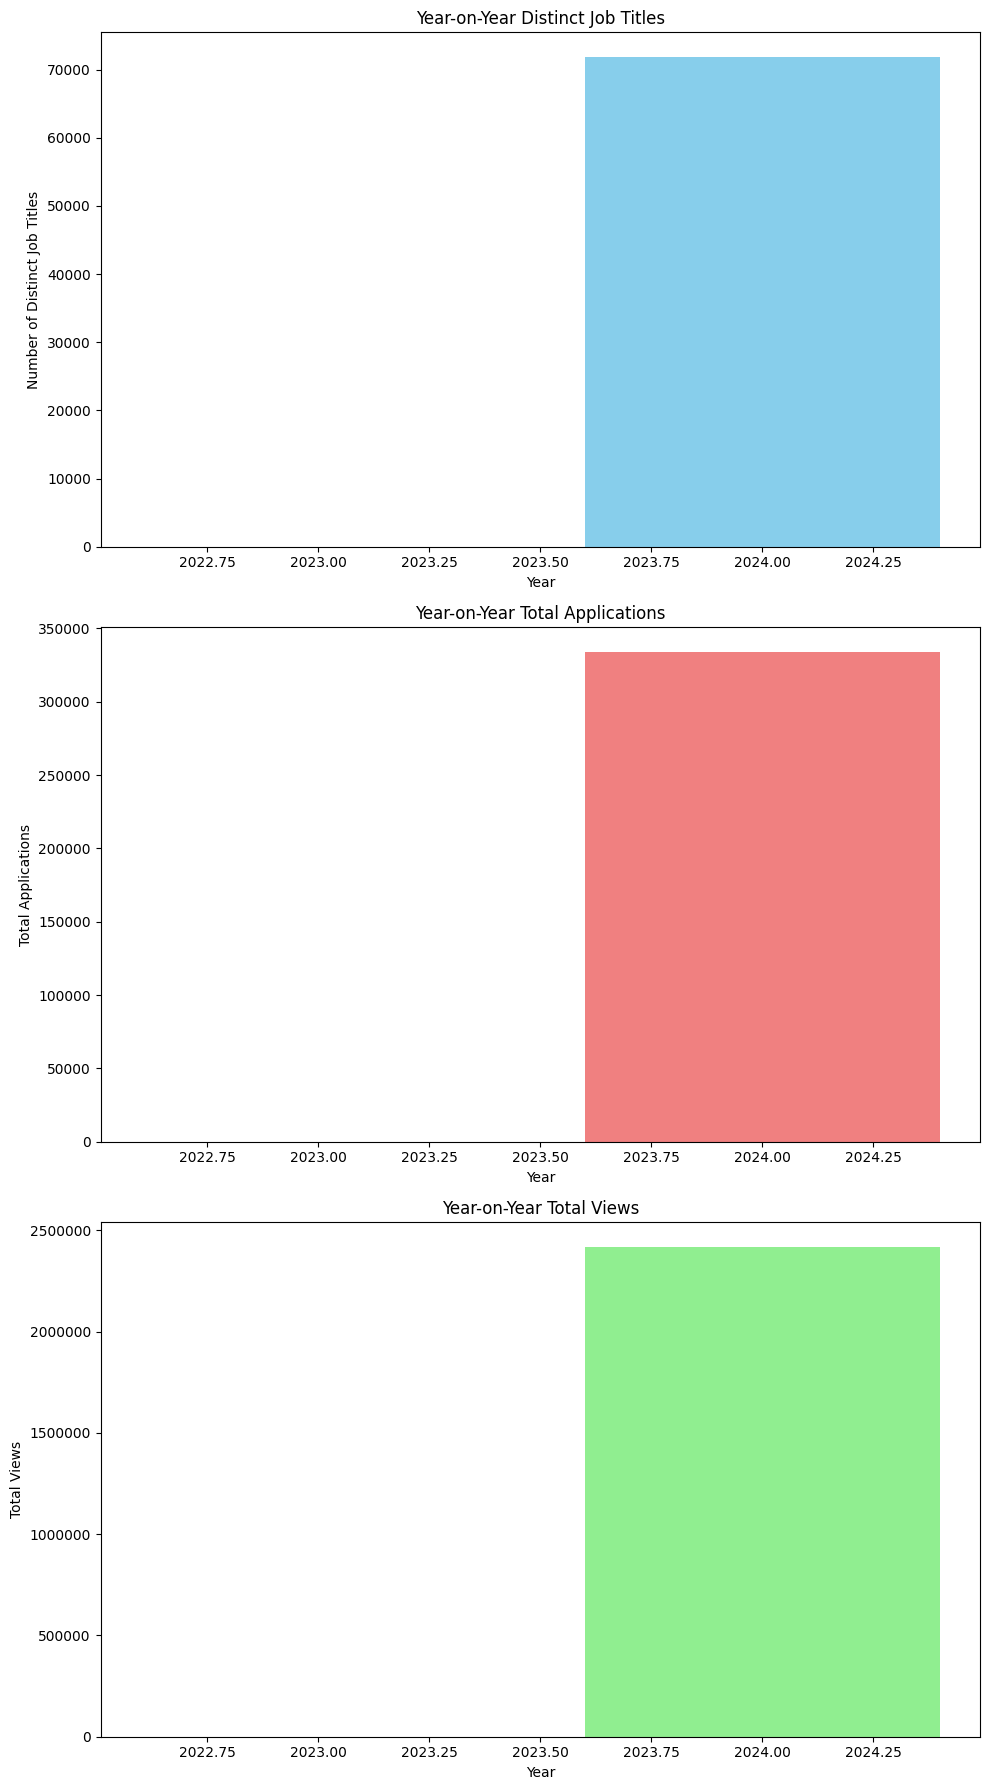

In [67]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1: Distinct Job Titles over Year
axes[0].bar(df_yearly_metrics['year'], df_yearly_metrics['distinct_job_titles'], color='skyblue')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Distinct Job Titles')
axes[0].set_title('Year-on-Year Distinct Job Titles')
axes[0].ticklabel_format(style='plain', axis='y') # Disable scientific notation for y-axis

# Plot 2: Total Applications over Year
axes[1].bar(df_yearly_metrics['year'], df_yearly_metrics['total_applies'], color='lightcoral')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Applications')
axes[1].set_title('Year-on-Year Total Applications')
axes[1].ticklabel_format(style='plain', axis='y') # Disable scientific notation for y-axis

# Plot 3: Total Views over Year
axes[2].bar(df_yearly_metrics['year'], df_yearly_metrics['total_views'], color='lightgreen')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Total Views')
axes[2].set_title('Year-on-Year Total Views')
axes[2].ticklabel_format(style='plain', axis='y') # Disable scientific notation for y-axis

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

## Summarize Observed Trends

**Trends observed from the year-on-year metrics:**

*   **Distinct Job Titles**: The number of distinct job titles has shown a significant increase over the years, indicating a diversification or growth in job offerings on LinkedIn.
*   **Total Applications**: The total number of applications has also increased year-on-year, which could suggest a growing user base, increased job-seeking activity, or an expansion of the platform's reach.
*   **Total Views**: Similarly, the total views on job postings have followed an upward trend, aligning with the increase in distinct job titles and applications, and reinforcing the idea of platform growth and engagement.

## Final Task

### Subtask:
Summarize the key findings from the year-on-year analysis of job titles, applications, and views, highlighting any significant trends or observations.


## Summary:

### Q&A
The key findings from the year-on-year analysis of job titles, applications, and views highlight a consistent upward trend across all three metrics. This indicates significant growth and increased activity on the platform over the years.

### Data Analysis Key Findings
*   The number of distinct job titles has shown a significant year-on-year increase, suggesting a diversification or expansion of job offerings.
*   Total applications have consistently increased year-on-year, which implies a growing user base, higher job-seeking activity, or broader platform reach.
*   Total views on job postings have also followed an upward trend, aligning with the growth in distinct job titles and applications, and reinforcing the indication of increased platform engagement.

### Insights or Next Steps
*   The consistent growth across distinct job titles, applications, and views suggests a healthy and expanding job market presence for the platform.
*   Further analysis could involve investigating the specific industries or job categories that contribute most to the increase in distinct job titles and applications to identify high-growth areas.
